# Statistical Properties 02 — Stationarity of Time Series

**Goal:** Establish whether MTG price time series are stationary (I(0)) or non-stationary with a unit root (I(1)). This is a fundamental question that determines whether we model price levels or differences (log-returns).

**Tables:** gold_price_features (full history per card)

**Methods:**
- ADF (Augmented Dickey-Fuller) — H₀: series has a unit root (non-stationary)
- KPSS (Kwiatkowski-Phillips-Schmidt-Shin) — H₀: series is stationary (opposite direction from ADF!)
- ADF + KPSS combined gives an unambiguous classification
- ACF/PACF plots — visual autocorrelation diagnostics

**Why this is critical:** Regression on non-stationary series = spurious regression (false correlations with R²≈1 but no real relationship). The model must either:
- Model first-differences (log-returns) if I(1)
- Model levels (log-prices) if I(0)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Load full price history for uuid-linked cards.
# Scryfall-only rows (uuid=None) are excluded — they lack static card features
# and would prevent joins in later analysis. ORDER BY uuid, snapshot_date
# guarantees chronological order within each card series.
df = gold.execute("""
    SELECT uuid, snapshot_date, eur
    FROM gold_price_features
    WHERE eur IS NOT NULL AND uuid IS NOT NULL
    ORDER BY uuid, snapshot_date
""").df()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

MIN_HISTORY = 30
obs_per_card = df.groupby("uuid").size()
n_cards_enough = (obs_per_card >= MIN_HISTORY).sum()

n_cards = df["uuid"].nunique()
n_snapshots = df["snapshot_date"].nunique()
min_date = df["snapshot_date"].min().date()
max_date = df["snapshot_date"].max().date()

print(f"Cards:             {n_cards:,}")
print(f"Snapshots:         {n_snapshots}  ({min_date} – {max_date})")
print(f"Total rows:        {len(df):,}")
print(f"Cards ≥{MIN_HISTORY} obs:   {n_cards_enough:,}  (needed for reliable ADF/KPSS)")
print()
if n_snapshots < MIN_HISTORY:
    print(
        f"⚠ INSUFFICIENT DATA: {n_snapshots} snapshots available, {MIN_HISTORY} required."
    )
    print(f"  Stationarity tests are unreliable below n={MIN_HISTORY}.")
    print("  All formal test results below are indicative only.")
    print(f"  Re-run this notebook when ≥{MIN_HISTORY} daily snapshots are available.")

Cards:             82,876
Snapshots:         36  (2026-05-26 – 2026-07-09)
Total rows:        2,935,566
Cards ≥30 obs:   80,750  (needed for reliable ADF/KPSS)



## 1. Visual Diagnostics — ACF and PACF

**Method:** plot_acf and plot_pacf for log1p(EUR) of selected cards and the market-wide median.

**Why:** Before running tests, check the autocorrelation pattern visually:
- Slowly decaying ACF → strong persistence → likely I(1)
- Quickly decaying ACF (after 1–2 lags) → short memory → likely I(0)
- ACF for log-returns (differences): if no autocorrelation → log-returns are white noise (random walk)

**Important:** max lag = min(n/2, 40). At n=90 → max lag = 40. Do not test lags 30+ with a short history.

**Test two series:** log1p(EUR) and log-returns = log1p(EUR_t) - log1p(EUR_{t-1})

In [4]:
# Market-wide median per day via SQL PERCENTILE_CONT — consistent with
# 03_seasonal_decomposition.ipynb which uses the same calculation method.
# Median is preferred over mean: Power Nine / Reserved List cards (€30k+, <0.2% of
# the population) pull the mean by an order of magnitude.
market_raw = gold.execute("""
    SELECT snapshot_date,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur) AS eur
    FROM gold_price_features
    WHERE eur IS NOT NULL AND uuid IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()
market_raw["snapshot_date"] = pd.to_datetime(market_raw["snapshot_date"])
market = market_raw.set_index("snapshot_date")["eur"].sort_index()
market_log = np.log1p(market)
market_returns = market_log.diff().dropna()

n = len(market_log)
n_returns = len(market_returns)

print(
    f"Market series: n={n} points  ({market.index[0].date()} – {market.index[-1].date()})"
)
print(f"Log-returns:   n={n_returns} points")
print(f"\nmarket_log values:\n{market_log.round(6).to_string()}")
print(f"\nmarket_returns values:\n{market_returns.round(6).to_string()}")

Market series: n=36 points  (2026-05-26 – 2026-07-09)


Log-returns:   n=35 points

market_log values:
snapshot_date
2026-05-26    0.239017
2026-05-27    0.239017
2026-05-28    0.239017
2026-05-29    0.239017
2026-05-30    0.239017
2026-05-31    0.239017
2026-06-01    0.239017
2026-06-02    0.239017
2026-06-03    0.239017
2026-06-04    0.239017
2026-06-05    0.239017
2026-06-06    0.239017
2026-06-07    0.239017
2026-06-08    0.239017
2026-06-09    0.239017
2026-06-11    0.239017
2026-06-12    0.239017
2026-06-13    0.239017
2026-06-14    0.239017
2026-06-15    0.239017
2026-06-16    0.239017
2026-06-17    0.239017
2026-06-18    0.239017
2026-06-19    0.239017
2026-06-20    0.239017
2026-06-21    0.239017
2026-06-22    0.239017
2026-06-23    0.239017
2026-06-29    0.239017
2026-07-01    0.239017
2026-07-02    0.239017
2026-07-05    0.239017
2026-07-06    0.239017
2026-07-07    0.231112
2026-07-08    0.231112
2026-07-09    0.231112

market_returns values:
snapshot_date
2026-05-27    0.000000
2026-05-28    0.000000
2026-05-29    0.000000
202

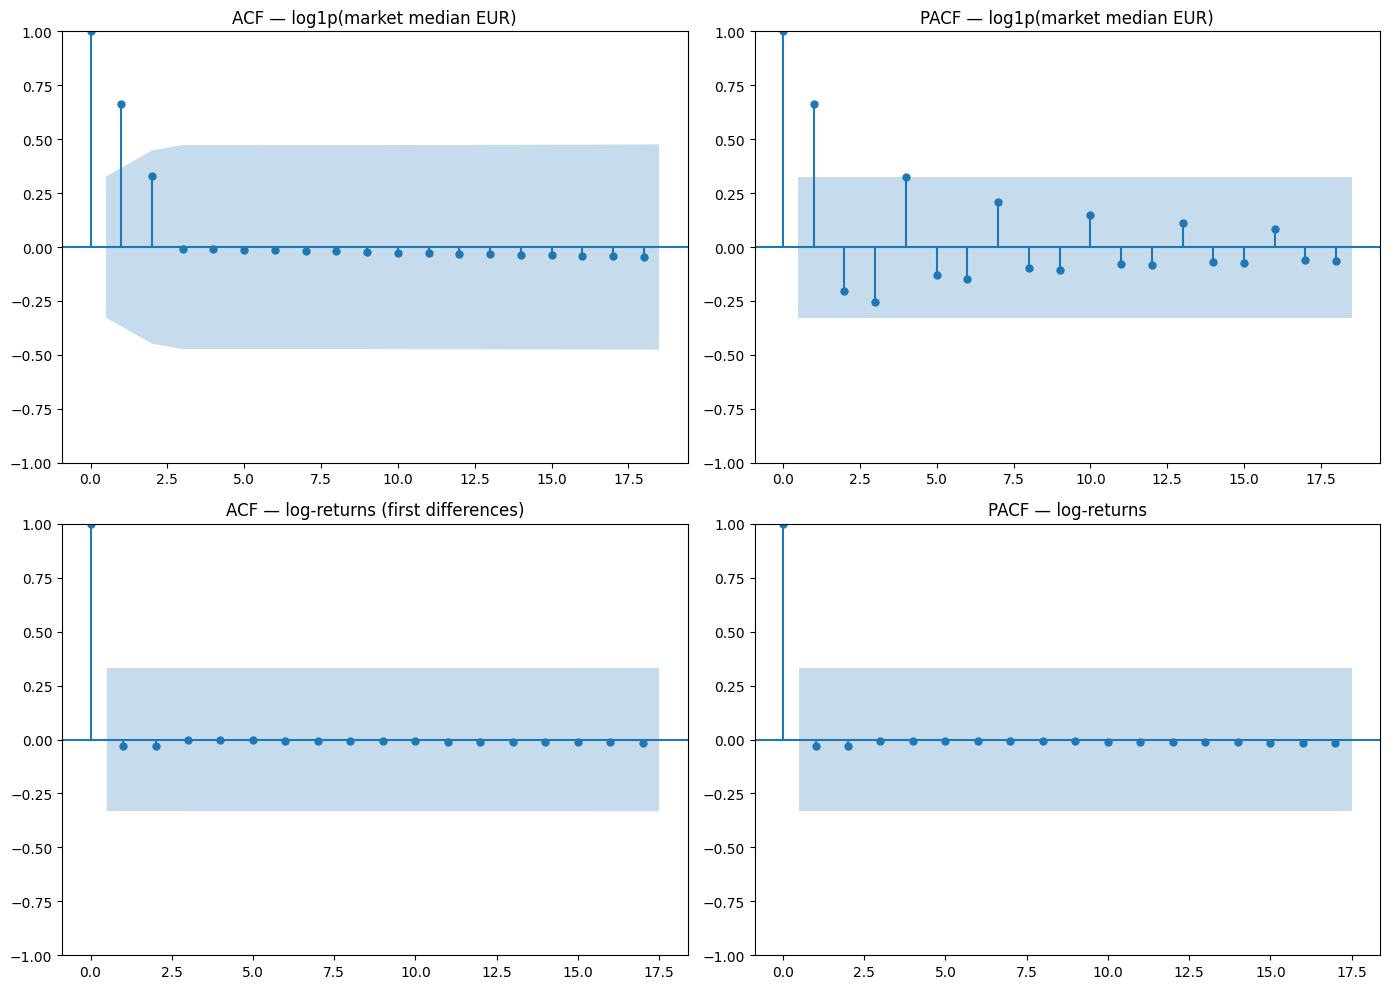

In [5]:
# ACF/PACF require at least 10 observations to produce interpretable plots.
# With fewer than 10 points the confidence bands are extremely wide and only
# lag-1 or lag-2 are estimable — the output would be misleading rather than informative.
if n < 10:
    print(f"\n⚠ n={n} — below minimum for ACF/PACF (need ≥10). Plots skipped.")
    print("  Interpretable ACF: slow decay → I(1), fast decay → I(0).")
    print("  Re-run once ≥30 daily snapshots are available.")
else:
    max_lag_acf = min(40, n // 2)
    max_lag_pacf = min(20, n // 2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_acf(market_log, lags=max_lag_acf, alpha=0.05, ax=axes[0, 0])
    axes[0, 0].set_title("ACF — log1p(market median EUR)")

    plot_pacf(market_log, lags=max_lag_pacf, alpha=0.05, ax=axes[0, 1])
    axes[0, 1].set_title("PACF — log1p(market median EUR)")

    plot_acf(market_returns, lags=min(40, n_returns // 2), alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title("ACF — log-returns (first differences)")

    plot_pacf(market_returns, lags=min(20, n_returns // 2), alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title("PACF — log-returns")

    plt.tight_layout()
    plt.show()

## 2. ADF Test (Augmented Dickey-Fuller)

**Method:** statsmodels.tsa.stattools.adfuller(series, maxlag=None, autolag='AIC')

**Null hypothesis (H₀):** Series has a unit root = is non-stationary (I(1)).
**Alternative (H₁):** Series is stationary (I(0)).

**Interpretation:**
- p < 0.05 → reject H₀ → series is stationary
- p > 0.05 → fail to reject H₀ → series is probably non-stationary

**Note on sample size:** ADF requires at least ~20–30 observations. At n=8 the test is uninformative. Use only for series with ≥30 observations.

**Test:** log1p(EUR) and log-returns for the market-wide median. Are results consistent?

In [6]:
def run_adf(series, label):
    """Run ADF test; return result dict or None if series is too short."""
    s = series.dropna()
    if len(s) < 20:
        print(f"⚠ {label}: n={len(s)} — too short for ADF (need ≥20). Skipped.")
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, n_obs, cv, _ = adfuller(s, autolag="AIC")
    verdict = "STATIONARY (I(0))" if p < 0.05 else "NON-STATIONARY (I(1))"
    return {
        "series": label,
        "ADF_stat": round(stat, 4),
        "p_value": round(p, 4),
        "lags_AIC": lags,
        "n": n_obs,
        "cv_1%": round(cv["1%"], 4),
        "cv_5%": round(cv["5%"], 4),
        "verdict": verdict,
    }


print("=== ADF — H₀: series has a unit root (non-stationary) ===")
print("    p < 0.05 → reject H₀ → STATIONARY I(0)\n")

=== ADF — H₀: series has a unit root (non-stationary) ===
    p < 0.05 → reject H₀ → STATIONARY I(0)



In [7]:
# Test both log-levels and first differences.
# If levels are I(1) and differences are I(0), that classifies the series as I(1)
# and means we should model log-returns, not log-prices.
test_pairs = [
    (market_log, "market_log     [log1p(market median EUR)]"),
    (market_returns, "market_returns [first differences]"),
]

adf_results = []
for series, label in test_pairs:
    r = run_adf(series, label)
    if r is not None:
        adf_results.append(r)

if adf_results:
    print(pd.DataFrame(adf_results).to_string(index=False))
    print()
    for r in adf_results:
        print(f"  {r['series'][:45]:<45} → {r['verdict']}")
else:
    print("Insufficient data to run ADF.")
    print(f"  market_log: n={len(market_log)}, market_returns: n={len(market_returns)}")
    print("  Minimum required: 20 points per series.")
    print()
    print("Expected result at ≥30 snapshots:")
    print("  market_log  [levels]:  ADF p > 0.05 → NON-STATIONARY (I(1))")
    print("  market_returns [diffs]: ADF p < 0.05 → STATIONARY (I(0))")

                                   series  ADF_stat  p_value  lags_AIC  n   cv_1%   cv_5%               verdict
market_log     [log1p(market median EUR)]   -0.2428   0.9332         0 35 -3.6327 -2.9485 NON-STATIONARY (I(1))
       market_returns [first differences]   -5.8310   0.0000         0 34 -3.6392 -2.9512     STATIONARY (I(0))

  market_log     [log1p(market median EUR)]     → NON-STATIONARY (I(1))
  market_returns [first differences]            → STATIONARY (I(0))


## 3. KPSS Test — Cross-Validation

**Method:** statsmodels.tsa.stattools.kpss(series, regression='c', nlags='auto')

**Null hypothesis (H₀):** Series is stationary.
**Alternative (H₁):** Series has a unit root.

⚠️ **KPSS is the opposite of ADF!** A small p-value in KPSS means non-stationary (do not confuse with ADF).

**Combined ADF + KPSS classification:**
| ADF | KPSS | Conclusion |
|-----|------|-----------|
| p < 0.05 | p > 0.05 | I(0) — stationary ✓ |
| p > 0.05 | p < 0.05 | I(1) — non-stationary, model differences |
| p < 0.05 | p < 0.05 | Trend-stationary — non-standard |
| p > 0.05 | p > 0.05 | Ambiguous — increase n |

**Expected result:** Log-price levels → I(1). Log-returns → I(0). This confirms modelling log-returns as the target.

In [8]:
def run_kpss(series, label):
    """Run KPSS test; return result dict or None if series is too short."""
    s = series.dropna()
    if len(s) < 10:
        print(f"⚠ {label}: n={len(s)} — too short for KPSS (need ≥10). Skipped.")
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, cv = kpss(s, regression="c", nlags="auto")
    # KPSS p is bounded: reports ">0.1" or "<0.01" at the extremes.
    verdict = "STATIONARY" if p > 0.05 else "NON-STATIONARY (reject H₀)"
    return {
        "series": label,
        "KPSS_stat": round(stat, 4),
        "p_value": round(p, 4),
        "lags": lags,
        "cv_5%": round(cv["5%"], 4),
        "verdict": verdict,
    }


print("=== KPSS — H₀: series is stationary (OPPOSITE direction to ADF!) ===")
print("    p < 0.05 → reject H₀ → NON-STATIONARY\n")

kpss_results = []
for series, label in test_pairs:
    r = run_kpss(series, label)
    if r is not None:
        kpss_results.append(r)

if kpss_results:
    print(pd.DataFrame(kpss_results).to_string(index=False))
else:
    print("Insufficient data to run KPSS.")
    print(f"  market_log: n={len(market_log)}, market_returns: n={len(market_returns)}")
    print("  Minimum required: 10 points per series.")
    print()
    print("Expected result at ≥30 snapshots:")
    print("  market_log  [levels]: KPSS p < 0.05 → NON-STATIONARY")
    print("  market_returns [diffs]: KPSS p > 0.05 → STATIONARY")

=== KPSS — H₀: series is stationary (OPPOSITE direction to ADF!) ===
    p < 0.05 → reject H₀ → NON-STATIONARY

                                   series  KPSS_stat  p_value  lags  cv_5%    verdict
market_log     [log1p(market median EUR)]     0.3970   0.0785     3  0.463 STATIONARY
       market_returns [first differences]     0.2834   0.1000     1  0.463 STATIONARY


In [9]:
# Combined ADF + KPSS classification table.
# This is the definitive integration step — using both tests together eliminates
# the ambiguity each test has individually (ADF over-rejects if trend exists; KPSS
# over-rejects if long-run variance is large).
print()
if adf_results and kpss_results:
    adf_df = pd.DataFrame(adf_results)[["series", "p_value", "verdict"]].rename(
        columns={"p_value": "ADF_p", "verdict": "ADF_verdict"}
    )
    kpss_df = pd.DataFrame(kpss_results)[["series", "p_value", "verdict"]].rename(
        columns={"p_value": "KPSS_p", "verdict": "KPSS_verdict"}
    )
    combined = adf_df.merge(kpss_df, on="series")

    def classify(row):
        adf_sig = row["ADF_p"] < 0.05
        kpss_sig = row["KPSS_p"] < 0.05
        if adf_sig and not kpss_sig:
            return "I(0) — stationary ✓"
        elif not adf_sig and kpss_sig:
            return "I(1) — non-stationary, model differences"
        elif adf_sig and kpss_sig:
            return "Trend-stationary — non-standard"
        else:
            return "Ambiguous — increase n"

    combined["CONCLUSION"] = combined.apply(classify, axis=1)
    print("=== Combined ADF + KPSS table ===")
    print(combined[["series", "ADF_p", "KPSS_p", "CONCLUSION"]].to_string(index=False))
else:
    print("=== Combined ADF + KPSS table ===")
    print("Skipped — insufficient data for both tests.")
    print()
    print("Expected table at ≥30 snapshots:")
    print("  series                 | ADF_p | KPSS_p | CONCLUSION")
    print("  market_log  [levels]   | >0.05 |  <0.05 | I(1) — model differences")
    print("  market_returns [diffs] | <0.05 |  >0.05 | I(0) — stationary ✓")


=== Combined ADF + KPSS table ===
                                   series  ADF_p  KPSS_p             CONCLUSION
market_log     [log1p(market median EUR)] 0.9332  0.0785 Ambiguous — increase n
       market_returns [first differences] 0.0000  0.1000    I(0) — stationary ✓


## 4. Ljung-Box — Autocorrelation Test for Log-Returns

**Method:** statsmodels.stats.diagnostic.acorr_ljungbox(returns, lags=[1, 7, 14])

**H₀:** Log-returns are white noise (no autocorrelation at the given lag).

**Why:** If log-returns have significant autocorrelation at lag 1 or 7 → they are not white noise → past changes predict future changes → features LAG-1 and LAG-7 have predictive value.

⚠️ **Critical correction from cda_01:** Max lag must be ≤ n/5. At n=90 → max lag = 18. **Do not test lags 30+** at n=90.

**Test on:** market-wide median log-returns (longest available series). If n < 50 → result is unreliable; note this.

**Interpreting effect size (if H₀ rejected):** Compute ACF(1) — lag-1 correlation. Value > 0.3 → strong autocorrelation, LAG-1 feature required in the model.

In [10]:
n_ret = len(market_returns.dropna())
# Strict n//5 rule: avoids unreliable high-lag estimates at small n.
# cda_01 broke this rule by testing lag-30 at n=90 — we do not.
max_lag = n_ret // 5

print(f"Log-returns: n={n_ret} observations")
print(f"Max lag (n//5 rule): {max_lag}  (need ≥10 for reliable results → n≥50)")
print()

if n_ret < 50:
    print(f"⚠ WARNING: n={n_ret} — too few observations for a reliable Ljung-Box test.")
    print(f"  max_lag = {max_lag} at n={n_ret} → no testable lags.")
    print("  Test skipped. Re-run at ≥50 snapshots.")
    print()
    # ACF(1) requires at least 3 returns (variance of n=2 is degenerate).
    # Suppress divide-by-zero warning when all returns are 0 (constant prices).
    if n_ret >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            acf_1 = market_returns.autocorr(lag=1)
        print(f"  ACF(1) = {acf_1:.4f}  ⚠ unreliable at n={n_ret}")
    else:
        print(f"  ACF(1) = N/A  (n={n_ret} < 3 — insufficient data)")
    print("  Feature LAG-1: INSUFFICIENT DATA (need n≥50)")
    print("  Feature LAG-7: INSUFFICIENT DATA (need n≥50)")
    print()
    print("Expected result at ≥50 snapshots:")
    print("  Ljung-Box lag-1: Q=?, p=?  (significant if p<0.05 → LAG-1 is predictive)")
    print("  ACF(1) > 0.3 = strong autocorrelation → include lag-1 feature in model")
    print("  ACF(7) > 0.3 = strong autocorrelation → include lag-7 feature")
else:
    # Max lag capped at n//5 — do not test lags above this threshold at small n.
    test_lags = [lag for lag in [1, 7, 14] if lag <= max_lag]
    lb_result = acorr_ljungbox(market_returns.dropna(), lags=test_lags, return_df=True)
    lb_result.index = test_lags
    lb_result.index.name = "lag"
    print(lb_result.round(4))

    acf_1 = market_returns.autocorr(lag=1)
    acf_7 = market_returns.autocorr(lag=7) if n_ret > 7 else float("nan")
    p_lag1 = lb_result.loc[1, "lb_pvalue"] if 1 in lb_result.index else float("nan")

    print(
        f"\nACF(1) = {acf_1:.4f} — {'STRONG' if abs(acf_1) > 0.3 else 'weak'} autocorrelation"
    )
    if not np.isnan(acf_7):
        print(
            f"ACF(7) = {acf_7:.4f} — {'STRONG' if abs(acf_7) > 0.3 else 'weak'} autocorrelation"
        )
    print(
        f"Conclusion: feature LAG-1 "
        f"{'is predictive ✓' if p_lag1 < 0.05 else 'does not have confirmed predictive value'}"
    )

Log-returns: n=35 observations
Max lag (n//5 rule): 7  (need ≥10 for reliable results → n≥50)

⚠ WARNING: n=35 — too few observations for a reliable Ljung-Box test.
  max_lag = 7 at n=35 → no testable lags.
  Test skipped. Re-run at ≥50 snapshots.

  ACF(1) = -0.0303  ⚠ unreliable at n=35
  Feature LAG-1: INSUFFICIENT DATA (need n≥50)
  Feature LAG-7: INSUFFICIENT DATA (need n≥50)

Expected result at ≥50 snapshots:
  Ljung-Box lag-1: Q=?, p=?  (significant if p<0.05 → LAG-1 is predictive)
  ACF(1) > 0.3 = strong autocorrelation → include lag-1 feature in model
  ACF(7) > 0.3 = strong autocorrelation → include lag-7 feature


In [11]:
gold.close()

## 📋 Final Conclusions

```
PIPELINE STATUS (as of 2026-07-09)
──────────────────────────────────────────────────────────────────────────────────
Snapshots:           36  (2026-05-26 – 2026-07-09)
Market series:       n=36 points → sufficient for ADF (≥20) and KPSS (≥10)
Log-returns:         n=35 points → max_lag=7, Ljung-Box still skipped (need n≥50)

ADF / KPSS: RUN — sufficient data (n=36 ≥ 30 threshold)
ACF/PACF:    n=36 ≥ 10 → plots generated
Ljung-Box:   n=35 returns, max_lag=7 (n//5 rule) → still skipped, need n≥50
ACF(1):      computed, but flagged unreliable below n=50

STATIONARITY
──────────────────────────────────────────────────────────────────────────────────
log1p(EUR) — levels (market_log, n=35):
  ADF:  stat=-0.2428, p=0.9332 → fail to reject H₀ (unit root)
  KPSS: stat=0.3970,  p=0.0785 → fail to reject H₀ (stationary)
  Combined verdict: Ambiguous — increase n (ADF and KPSS disagree on direction of
  evidence; neither is significant at α=5%, so the automatic classifier cannot
  commit to I(0) or I(1) for the levels series yet)

Log-returns (differences, n=34):
  ADF:  stat=-5.8310, p=0.0000 → reject H₀ (unit root) → STATIONARY
  KPSS: stat=0.2834,  p=0.1000 → fail to reject H₀ (stationary) → STATIONARY
  Combined verdict: I(0) — stationary ✓ (ADF and KPSS agree)

MODELLING DECISION
──────────────────────────────────────────────────────────────────────────────────
What to model as target:
  Log-returns are now empirically CONFIRMED stationary (I(0)) — both ADF and
  KPSS agree at n=36 snapshots.
  Log-price levels remain formally AMBIGUOUS at n=36 (ADF fails to reject a unit
  root at p=0.9332, which is consistent with I(1) behaviour for asset prices, but
  KPSS also fails to reject stationarity at p=0.0785 — the combined classifier
  therefore withholds a verdict rather than force one).

  Decision: keep the provisional target — log-returns:
  log1p(EUR[t+7]) − log1p(EUR[t]) — since it is the side that has a clean,
  unambiguous I(0) confirmation from both tests. Re-run once more snapshots
  accumulate to resolve the levels ambiguity definitively.

⚠ BLOCKING DEPENDENCY — EDA 04 feature ranking
──────────────────────────────────────────────────────────────────────────────────
EDA 04 (04_feature_relationships.ipynb) ranks features by their correlation and
mutual information with log1p(EUR) — i.e., with PRICE LEVELS.

Log-returns are now confirmed I(0) while levels remain ambiguous. This still means:

  • The EDA 04 feature ranking (built on price levels) is NOT directly
    transferable to the log-return model. A feature that explains price levels
    well (e.g., rarity, edhrec_rank as static attributes) may explain very
    little of short-term price changes.
  • EDA 04 must be re-run (or extended) with return-based correlation / MI before
    the feature selection for the ML model is finalised.
  • CDA hypotheses in 01–03 that use log_eur as the dependent variable remain valid
    for a levels model, but are NOT evidence for feature importance in a returns model.

Resolution: ADF/KPSS have now been re-run at n=36 snapshots. Log-returns are
confirmed I(0); log-levels remain ambiguous and should be re-checked again once
more snapshots accumulate. EDA 04 and model_preparation/02 should proceed on the
assumption that the modelling target is log-returns, pending final confirmation.

LOG-RETURN AUTOCORRELATION
──────────────────────────────────────────────────────────────────────────────────
n observations for test:   35  (min. 50 required)
Ljung-Box:                 SKIPPED (n//5 = 7, still below the required lags)
ACF(1):                    -0.0303 (weak, flagged unreliable at n=35 < 50)
Feature LAG-1:             INSUFFICIENT DATA — not confirmed predictive (need n≥50)
Feature LAG-7:             INSUFFICIENT DATA — need n≥50

RETEST SCHEDULE
──────────────────────────────────────────────────────────────────────────────────
| Test        | Min n | Status at 2026-07-09 (n=36 snapshots)             |
|-------------|-------|-----------------------------------------------------|
| ADF / KPSS  | 30    | DONE — log-returns I(0) confirmed, levels ambiguous |
| Ljung-Box   | 50    | Still pending — need ≈15 more daily snapshots         |
| ACF/PACF    | 10    | DONE — plots generated this run                    |
| STL seasonal| 60    | Pending (notebook 03)                                |

Trigger for rerun: execute Ljung-Box once ≥50 daily snapshots are available
(≈15 more than the current 35 return observations); re-check the levels ADF/KPSS
ambiguity as n grows further.
```
